## EDA

Loading Dataset

In [2]:
from datasets import load_dataset

dataset = load_dataset("dbpedia_14")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 70000
    })
})


Change dataset to Pandas Frame

In [3]:
import pandas as pd
df_train = pd.DataFrame(dataset["train"])
df_test = pd.DataFrame(dataset["test"])
print("train shape:", df_train.shape)
print("test shape:", df_test.shape)

train shape: (560000, 3)
test shape: (70000, 3)


In [4]:
# Xem thử hàng đầu tiên
print(df_train.iloc[0])

label                                                      0
title                                       E. D. Abbott Ltd
content     Abbott of Farnham E D Abbott Limited was a Br...
Name: 0, dtype: object


Labelling for each classes

In [5]:
label_names = [
    "Company",
    "EducationalInstitution",
    "Artist",
    "Athlete",
    "OfficeHolder",
    "MeanOfTransportation",
    "Building",
    "NaturalPlace",
    "Village",
    "Animal",
    "Plant",
    "Album",
    "Film",
    "WrittenWork"
]
df_train["label_name"] = df_train["label"].map(lambda x: label_names[x])
df_test["label_name"] = df_test["label"].map(lambda x: label_names[x])
print(df_train.iloc[0])

label                                                         0
title                                          E. D. Abbott Ltd
content        Abbott of Farnham E D Abbott Limited was a Br...
label_name                                              Company
Name: 0, dtype: object


Visualizing classes distribution

In [6]:
import matplotlib.pyplot as plt
class_counts = df_train["label_name"].value_counts()
print(class_counts)

label_name
Company                   40000
EducationalInstitution    40000
Artist                    40000
Athlete                   40000
OfficeHolder              40000
MeanOfTransportation      40000
Building                  40000
NaturalPlace              40000
Village                   40000
Animal                    40000
Plant                     40000
Album                     40000
Film                      40000
WrittenWork               40000
Name: count, dtype: int64


Visualizing

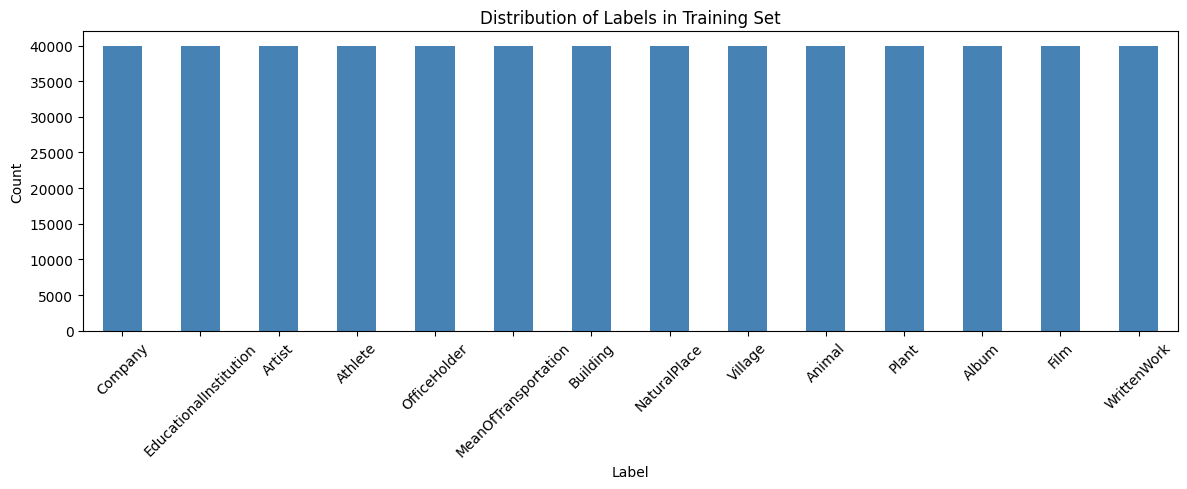

In [7]:
plt.figure(figsize=(12,5))
class_counts.plot(kind="bar", color="steelblue")
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
df_train["text_length"] = df_train["content"].apply(lambda x: len(x.split()))
print(df_train["text_length"].describe())

count    560000.000000
mean         46.133234
std          22.469181
min           1.000000
25%          27.000000
50%          46.000000
75%          65.000000
max        1484.000000
Name: text_length, dtype: float64


Visualizing

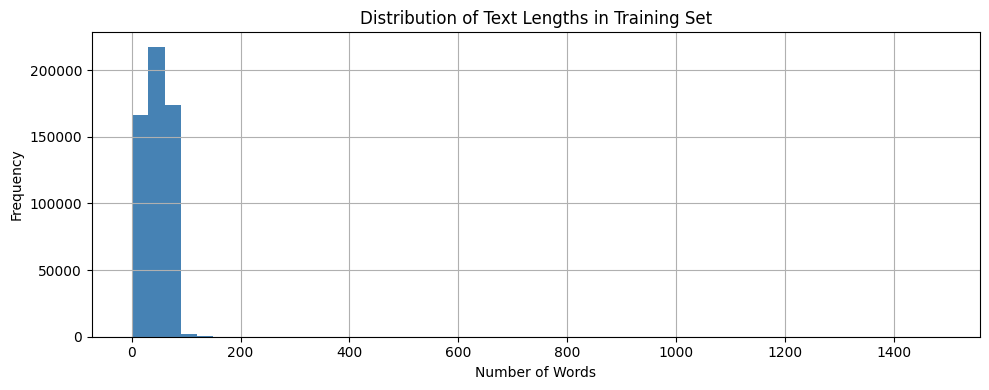

In [37]:
plt.figure(figsize=(10,4))
df_train["text_length"].hist(bins=50, color="steelblue")
plt.title("Distribution of Text Lengths in Training Set")
plt.ylabel("Frequency")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.show()

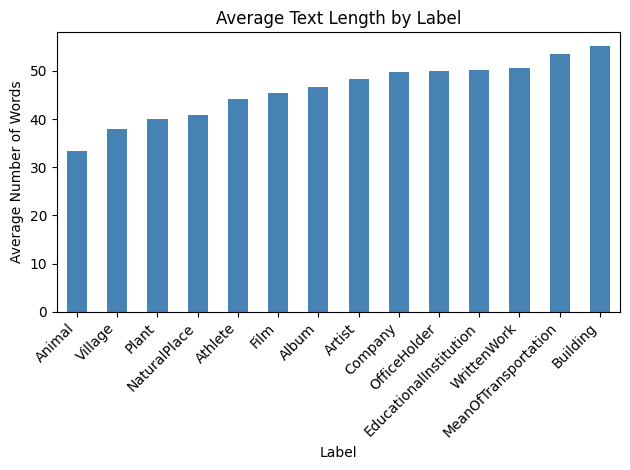

In [87]:
avg_length = df_train.groupby("label_name")["text_length"].mean().sort_values()
avg_length.plot(kind="bar", color="steelblue")
plt.title("Average Text Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=45, ha = "right")
plt.tight_layout()
plt.show()

Checking Null

In [88]:
print(df_train.isnull().sum())

label          0
title          0
content        0
label_name     0
text_length    0
dtype: int64


## PREPROCESSING

2.1 Cleaning Text

In [89]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_train["clean_content"] = df_train["content"].apply(clean_text)
df_test["clean_content"] = df_test["content"].apply(clean_text)

print("Trước:", df_train["content"][0])
print("---")
print("Sau:  ", df_train["clean_content"][0])

Trước:  Abbott of Farnham E D Abbott Limited was a British coachbuilding business based in Farnham Surrey trading under that name from 1929. A major part of their output was under sub-contract to motor vehicle manufacturers. Their business closed in 1972.
---
Sau:   abbott of farnham e d abbott limited was a british coachbuilding business based in farnham surrey trading under that name from 1929 a major part of their output was under subcontract to motor vehicle manufacturers their business closed in 1972


2.2 Tokenization for BERT

In [ ]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
sample = df_train["clean_content"][0]
tokens = tokenizer(
    sample,
    max_length=128,
    truncation=True,        # truncate if text is longer than max_length
    padding="max_length",   #add Padding
    return_tensors="pt"     #return pyTorch form
)
print("Input Shape: ", tokens["input_ids"].shape)
print("Input IDs: ", tokens["input_ids"])
print("Attention Mask: ", tokens["attention_mask"])

Input Shape:  torch.Size([1, 128])
Input IDs:  tensor([[  101, 14455,  1997,  2521, 20465,  1041,  1040, 14455,  3132,  2001,
          1037,  2329,  2873, 25820,  2449,  2241,  1999,  2521, 20465,  9948,
          6202,  2104,  2008,  2171,  2013,  4612,  1037,  2350,  2112,  1997,
          2037,  6434,  2001,  2104,  4942,  8663,  6494,  6593,  2000,  5013,
          4316,  8712,  2037,  2449,  2701,  1999,  3285,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
     

Dataset classes 

In [91]:
import torch
from torch.utils.data import Dataset, DataLoader

class DBpediaDataset(Dataset):
    
    def __init__(self, df, tokenizer, max_length=128):
        self.df = df
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        text = self.df["clean_content"].iloc[idx]
        label = self.df["label"].iloc[idx]

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),  # remove batch dimension
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label, dtype=torch.long)
        }

Data Loader

In [92]:
train_dataset = DBpediaDataset(df_train, tokenizer)
test_dataset = DBpediaDataset(df_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

batch = next(iter(train_loader))
print("Input IDs shape: ", batch["input_ids"].shape)
print("Label shape: ", batch["labels"].shape)

Input IDs shape:  torch.Size([32, 128])
Label shape:  torch.Size([32])


## Modeling

BERT Model

In [93]:
from transformers import BertForSequenceClassification
import torch

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=14)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device: ", device)
print("Model loaded!")


      

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Device:  cuda
Model loaded!


Optimizer and Loss Function

In [94]:
from torch.optim import AdamW
from transformers import get_scheduler

optimizer = AdamW(model.parameters(), lr=2e-5)

num_epochs = 3
num_training_steps = num_epochs * len(train_loader)

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

print("Optimizer is ready!")
print("Number of training steps: ", num_training_steps)

Optimizer is ready!
Number of training steps:  52500


Train Loop

In [95]:
from tqdm import tqdm

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids, 
            attention_mask=attention_mask, 
            labels=labels)
        
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        
        # Collect predictions for accuracy
        preds = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    train_acc = accuracy_score(all_labels, all_preds)
    return avg_loss, train_acc

Evaluation Loop

In [96]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids, 
                attention_mask=attention_mask
            )
            
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    return acc, f1

Training

In [97]:
for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    test_acc, f1 = evaluate(model, test_loader, device)
    
    # Calculate overfit gap
    overfit_gap = train_acc - test_acc
    
    print(f"Train Loss:  {train_loss:.4f}")
    print(f"Train Acc:   {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"Test Acc:    {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Overfit Gap: {overfit_gap:.4f} ({overfit_gap*100:.2f}%)")
    print(f"F1 Score:    {f1:.4f}")
    
    #save the checkpoint
    torch.save(model.state_dict(), f"bert_model_epoch_{epoch+1}.pt")
    print(f"Model saved to bert_model_epoch_{epoch+1}.pt")


--- Epoch 1/3 ---


Training:   1%|          | 153/17500 [14:15<26:55:47,  5.59s/it]



KeyboardInterrupt: 

Resume Training from Checkpoint

In [ ]:
import os
import glob

# Find all checkpoint files
checkpoints = glob.glob("bert_model_epoch_*.pt")
print("Available checkpoints:", checkpoints)

if checkpoints:
    # Get the latest checkpoint (highest epoch number)
    latest_checkpoint = max(checkpoints, key=lambda x: int(x.split("_")[-1].split(".")[0]))
    print(f"Latest checkpoint: {latest_checkpoint}")
    
    # Load it
    model.load_state_dict(torch.load(latest_checkpoint))
    print(f"Model loaded from {latest_checkpoint}")
else:
    print("No checkpoints found")

Available checkpoints: ['bert_model_epoch_1.pt', 'bert_model_epoch_2.pt']
Latest checkpoint: bert_model_epoch_2.pt
Model loaded from bert_model_epoch_2.pt


In [ ]:

# Function to get train accuracy from checkpoint by re-evaluating on train set
def get_train_accuracy_from_checkpoint(checkpoint_path, model, train_loader, device):
    """Load checkpoint and calculate train accuracy"""
    try:
        model.load_state_dict(torch.load(checkpoint_path))
        model.eval()
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(train_loader, desc="Evaluating Train"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                preds = outputs.logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        return accuracy_score(all_labels, all_preds)
    except Exception as e:
        print(f"Error calculating train accuracy: {e}")
        return None

# Display results for epochs 1 and 2
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS - EPOCHS 1 & 2")
print("=" * 80)

for epoch_num in [1, 2]:
    checkpoint_path = f"bert_model_epoch_{epoch_num}.pt"
    
    try:
        # Get train accuracy
        train_acc = get_train_accuracy_from_checkpoint(checkpoint_path, model, train_loader, device)
        
        # Get test accuracy
        model.load_state_dict(torch.load(checkpoint_path))
        test_acc, f1 = evaluate(model, test_loader, device)
        
        if train_acc is not None:
            overfit_gap = test_acc - train_acc
            
            print(f"   Epoch {epoch_num}:")
            print(f"   Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
            print(f"   Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
            print(f"   Overfit Gap:    {overfit_gap:.4f} ({overfit_gap*100:.2f}%)")
            print(f"   F1 Score:       {f1:.4f}")
            
            # Interpretation
            if abs(overfit_gap) < 0.01:  # Less than 1%
                print(f"   Status: NO OVERFITTING - Model generalizes well!")
            elif abs(overfit_gap) < 0.03:  # 1-3%
                print(f"   Status: MILD OVERFITTING - Acceptable")
            elif abs(overfit_gap) < 0.05:  # 3-5%
                print(f"   : MODERATE OVERFITTING - Consider regularization")
            else:  # > 5%
                print(f"   Status: SEVERE OVERFITTING - Model needs improvement")
    
    except FileNotFoundError:
        print(f"\nEpoch {epoch_num}: Checkpoint not found ({checkpoint_path})")
    except Exception as e:
        print(f"\nEpoch {epoch_num}: Error - {str(e)}")

print("\n" + "=" * 80)



OVERFITTING ANALYSIS - EPOCHS 1 & 2



OVERFITTING ANALYSIS - EPOCHS 1 & 2


Evaluating Train: 100%|██████████| 17500/17500 [38:48<00:00,  7.52it/s]

Evaluating: 100%|██████████| 2188/2188 [05:06<00:00,  7.13it/s]




OVERFITTING ANALYSIS - EPOCHS 1 & 2


Evaluating Train: 100%|██████████| 17500/17500 [38:48<00:00,  7.52it/s]

Evaluating: 100%|██████████| 2188/2188 [05:06<00:00,  7.13it/s]



...


OVERFITTING ANALYSIS - EPOCHS 1 & 2


Evaluating Train: 100%|██████████| 17500/17500 [38:48<00:00,  7.52it/s]

Evaluating: 100%|██████████| 2188/2188 [05:06<00:00,  7.13it/s]



   Epoch 1:
   Train Accuracy: 0.9986 (99.86%)
   Test Accuracy:  0.9927 (99.27%)
   Overfit Gap:    -0.0059 (-0.59%)
   F1 Score:       0.9927
   Status: NO OVERFITTING - Model generalizes well!


Evaluating Train: 100%|██████████| 17500/17500 [39:18<00:00,  7.42it/s]

Evaluating: 100%|██████████| 2188/2188 [05:04<00:00,  7.19it/s]

   Epoch 2:
   Train Accuracy: 0.9986 (99.86%)
   Test Accuracy:  0.9927 (99.27%)
   Overfit Gap:    -0.0059 (-0.59%)
   F1 Score:       0.9927
   Status: NO OVERFITTING - Model generalizes well!



LSTM (RNN) Models

In [98]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re 

Vocabulary

In [99]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower())

def build_vocab(df, max_vocab=30000):
    counter = Counter()
    for sample in df["clean_content"]:
        tokens = tokenize(sample)
        counter.update(tokens)

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab - 2):  # reserve 2 for PAD and UNK
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(df_train)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 30000


Custom Dataset

In [113]:
class DBpediaDataset(Dataset):
    def __init__(self, df, vocab, max_length=128):
        self.df = df
        self.vocab = vocab
        self.max_length = max_length
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        text = self.df["clean_content"].iloc[idx]
        label = self.df["label"].iloc[idx]

        tokens = tokenize(text)
        input_ids = [self.vocab.get(token, self.vocab["<UNK>"]) for token in tokens]
        
        # Pad or truncate
        if len(input_ids) < self.max_length:
            input_ids += [self.vocab["<PAD>"]] * (self.max_length - len(input_ids))
        else:
            input_ids = input_ids[:self.max_length]
        
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(label, dtype=torch.long)
        }

DataLoader

In [114]:
train_dataset = DBpediaDataset(df_train, vocab)
test_dataset = DBpediaDataset(df_test, vocab)

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64)

LSTM model

In [115]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes):
        super().__init__()
        self. embedding = nn.Embedding(vocab_size, embed_dim, padding_idx = 0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers = num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = torch.cat((hidden[-2],hidden[-1]), dim = 1)
        return self.fc(out)

Model initialization, Optimizer, Loss function

In [116]:
model = LSTMClassifier(
    vocab_size=len(vocab),
    embed_dim = 128,
    hidden_dim= 256,
    num_layers = 2,
    num_classes = 14
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

Training Loop

In [117]:
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0,0

    pbar = tqdm(loader, desc="Training")
    for batch_idx in pbar:
        text = batch_idx["input_ids"].to(device)
        label = batch_idx["labels"].to(device)

        optimizer.zero_grad()
        output = model(text)
        loss = criterion(output, label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_correct += (output.argmax(1) == label).sum().item()
    
    avg_loss = total_loss / len(loader)
    accuracy = total_correct / len(loader.dataset)

    return avg_loss, accuracy

Evaluation

In [118]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct = 0, 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")
        for batch_idx in pbar:
            text = batch_idx["input_ids"].to(device)
            label = batch_idx["labels"].to(device)

            output = model(text)
            loss = criterion(output, label)

            total_loss += loss.item()
            total_correct += (output.argmax(1) == label).sum().item()

        avg_loss = total_loss / len(loader)
        accuracy = total_correct /len(loader.dataset)
        return avg_loss, accuracy

Training

In [2]:
NUM_EPOCHS = 3
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test  Loss: {test_loss:.4f}  | Test  Acc: {test_acc:.4f}")    


--- Epoch 1/3 ---


NameError: name 'train' is not defined